In [1]:
import glob
import json
import os
import re
import zipfile
import queue
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import requests
import hnswlib
from html2text import html2text
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

In [2]:
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

In [3]:
rows = []

with zipfile.ZipFile(os.path.expanduser(
    "~/Box/dsi-core/11th-hour/idi-corporate-structure/submissions.zip"
)) as zf:
    namelist = list(zf.namelist())
    for filename in tqdm(namelist):
        if filename.startswith("CIK") and filename.endswith(".json"):
            cik = filename[3:-5]

            with zf.open(filename) as file:
                data = json.load(file)

            nyse = []
            nasdaq = []
            cboe = []
            otc = []
            for ticker, exchange in zip(data.get("tickers", []), data.get("exchanges", [])):
                if exchange == "NYSE":
                    nyse.append(ticker)
                elif exchange == "Nasdaq":
                    nasdaq.append(ticker)
                elif exchange == "CBOE":
                    cboe.append(ticker)
                elif exchange == "OTC":
                    otc.append(ticker)

            rows.append({
                "cik": cik,
                "ein": data.get("ein"),
                "lei": data.get("lei"),
                "name": data.get("name"),
                "stateOfIncorporation": data.get("stateOfIncorporation"),
                "addr_street1": data.get("addresses", {}).get("mailing", {}).get("street1"),
                "addr_street2": data.get("addresses", {}).get("mailing", {}).get("street2"),
                "addr_city": data.get("addresses", {}).get("mailing", {}).get("city"),
                "addr_stateOrCountry": data.get("addresses", {}).get("mailing", {}).get("stateOrCountry"),
                "addr_zipCode": data.get("addresses", {}).get("mailing", {}).get("zipCode"),
                "addr_country": data.get("addresses", {}).get("mailing", {}).get("country"),
                "busn_street1": data.get("addresses", {}).get("business", {}).get("street1"),
                "busn_street2": data.get("addresses", {}).get("business", {}).get("street2"),
                "busn_city": data.get("addresses", {}).get("business", {}).get("city"),
                "busn_stateOrCountry": data.get("addresses", {}).get("business", {}).get("stateOrCountry"),
                "busn_zipCode": data.get("addresses", {}).get("business", {}).get("zipCode"),
                "busn_country": data.get("addresses", {}).get("business", {}).get("country"),
                "nyse": ",".join(nyse),
                "nasdaq": ",".join(nasdaq),
                "cboe": ",".join(cboe),
                "otc": ",".join(otc),
            })

submissions = pd.DataFrame(rows)

  0%|          | 0/937121 [00:00<?, ?it/s]

In [6]:
subsidiaries = pd.read_csv("~/Box/dsi-core/11th-hour/idi-corporate-structure/subsidiaries-from-exhibits-21-8.csv", dtype=str)
subsidiaries["exhibit"] = subsidiaries["exhibit"].astype(int)

In [7]:
model = SentenceTransformer("Vsevolod/company-names-similarity-sentence-transformer")

In [8]:
DOT_COM = re.compile(r"\.COM\b")
DROP_PARENS = re.compile(r"\s*\([^)]*\)\s*")
DROP_TOKENS = re.compile(r"[.,-/'#:\\]")
ABBREVIATIONS = {
    "CORPORATION": "CORP",
    "COMPANY": "CO",
    "INCORPORATED": "INC",
    "LIMITED": "LTD",
    "ASSOCIATES": "ASSOC",
    "ASSOCIATION": "ASSOC",
    "TELEVISION": "TV",
    "USA": "US",

    "ACQUISITIONS": "ACQUISITION",
    "COMMUNICATIONS": "COMMUNICATION",
    "DEVELOPMENTS": "DEVELOPMENT",
    "ENTERPRISES": "ENTERPRISE",
    "FINANCES": "FINANCE",
    "FINANCIALS": "FINANCIAL",
    "FOUNDATIONS": "FOUNDATION",
    "FUNDINGS": "FUNDING",
    "FUNDS": "FUND",
    "HOLDINGS": "HOLDING",
    "INDUSTRIES": "INDUSTRY",
    "INVESTMENTS": "INVESTMENT",
    "INVESTORS": "INVESTOR",
    "PARTNERS": "PARTNER",
    "RESOURCES": "RESOURCE",
    "SECURITIES": "SECURITY",
    "SERVICES": "SERVICE",
    "SOLUTIONS": "SOLUTION",
    "SYSTEMS": "SYSTEM",
    "TECHNOLOGIES": "TECHNOLOGY",
    "VENTURES": "VENTURE",
}
def clean_name(name):
    return " ".join([
        ABBREVIATIONS.get(word, word)
        for word in DROP_TOKENS.sub(" ", DROP_PARENS.sub("", DOT_COM.sub(" DOT_COM ", name.upper()))).replace("&", " AND ").split()
    ]) if isinstance(name, str) else None

submissions_nodup = submissions[["cik", "name"]].copy()
submissions_nodup["name"] = submissions_nodup["name"].apply(clean_name)
submissions_nodup = submissions_nodup.dropna().drop_duplicates("name").reset_index(drop=True)
submissions_nodup["name_set"] = submissions_nodup["name"].apply(lambda name: " ".join(sorted(set(name.split()))))

subsidiary_nodup = subsidiaries[["subsidiary", "place"]].rename(columns={"subsidiary": "name"})
subsidiary_nodup["name"] = subsidiary_nodup["name"].apply(clean_name)
subsidiary_nodup = subsidiary_nodup.dropna().drop_duplicates("name").reset_index(drop=True)
subsidiary_nodup["name_set"] = subsidiary_nodup["name"].apply(lambda name: " ".join(sorted(set(name.split()))))

exact_cik = subsidiary_nodup.merge(submissions_nodup[["name", "cik"]], on="name", how="left").groupby("name").first()
set_cik = subsidiary_nodup.merge(submissions_nodup[["name_set", "cik"]], on="name_set", how="left")[["name", "cik"]].groupby("name").first()

subsidiary_nodup = subsidiary_nodup.set_index("name")
subsidiary_nodup["exact_cik"] = exact_cik["cik"]
subsidiary_nodup["set_cik"] = set_cik["cik"]
subsidiary_nodup = subsidiary_nodup.reset_index("name")

In [9]:
np.count_nonzero(subsidiary_nodup["exact_cik"].notna()) / len(subsidiary_nodup)

np.float64(0.11277365971384244)

In [10]:
np.count_nonzero(subsidiary_nodup["set_cik"].notna()) / len(subsidiary_nodup)

np.float64(0.11310857733888247)

In [11]:
submission_names = model.encode(submissions_nodup["name"].tolist())

In [12]:
subsidiary_names = model.encode(subsidiary_nodup["name"].tolist())

In [13]:
search_index = hnswlib.Index(space="cosine", dim=submission_names.shape[1])
search_index.init_index(max_elements=len(submission_names))
search_index.add_items(submission_names, np.arange(len(submission_names)))

In [14]:
labels, distances = search_index.knn_query(subsidiary_names, k=3)

In [15]:
subsidiary_nodup["match1_name"] = submissions_nodup.iloc[labels[:, 0]]["name"].reset_index(drop=True)
subsidiary_nodup["match1_cik"] = submissions_nodup.iloc[labels[:, 0]]["cik"].reset_index(drop=True)
subsidiary_nodup["match1_distance"] = distances[:, 0]

subsidiary_nodup["match2_name"] = submissions_nodup.iloc[labels[:, 1]]["name"].reset_index(drop=True)
subsidiary_nodup["match2_cik"] = submissions_nodup.iloc[labels[:, 1]]["cik"].reset_index(drop=True)
subsidiary_nodup["match2_distance"] = distances[:, 1]

subsidiary_nodup["match3_name"] = submissions_nodup.iloc[labels[:, 2]]["name"].reset_index(drop=True)
subsidiary_nodup["match3_cik"] = submissions_nodup.iloc[labels[:, 2]]["cik"].reset_index(drop=True)
subsidiary_nodup["match3_distance"] = distances[:, 2]

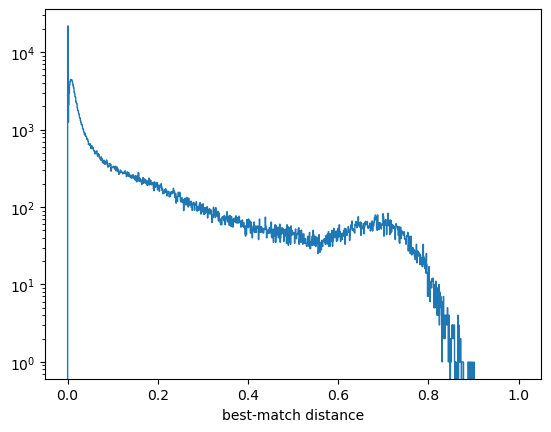

In [16]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 1), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

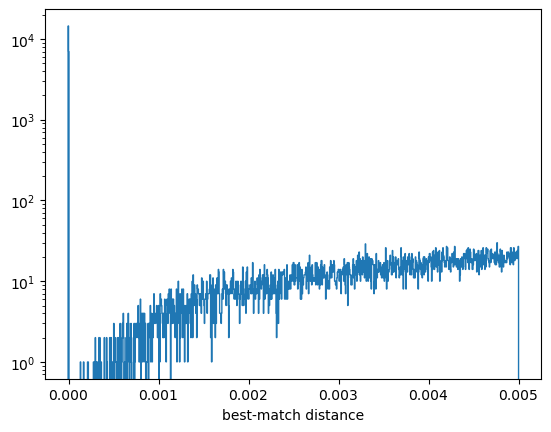

In [17]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 5e-3), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

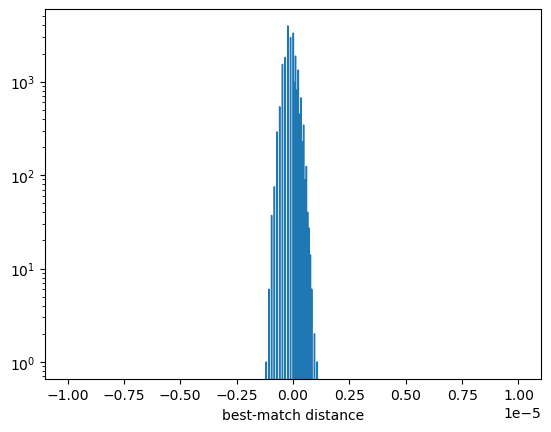

In [18]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 1e-5), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

In [19]:
subsidiary_nodup.query("match1_distance < 1e-5")[["name", "match1_name", "match1_cik", "exact_cik"]]

,name,match1_name,match1_cik,exact_cik
29,ATLANTIC PROSPECT INC,ATLANTIC PROSPECT INC,0001074830,0001074830
31,CENTURY PRINCE STREET INC,CENTURY PRINCE STREET INC,0001626716,0001626716
33,FUEL OUTDOOR LLC,FUEL OUTDOOR LLC,0001334628,0001334628
34,FUEL OUTDOOR HOLDING LLC,FUEL OUTDOOR HOLDING LLC,0001350495,0001350495
35,FUEL OUTDOOR SAN FRANCISCO LLC,FUEL OUTDOOR SAN FRANCISCO LLC,0001626748,0001626748
...,...,...,...,...
202934,CACTUS WASTE SYSTEM LLC,CACTUS WASTE SYSTEM LLC,0001485873,0001485873
202936,JACKSONVILLE FLORIDA LANDFILL INC,JACKSONVILLE FLORIDA LANDFILL INC,0001300434,0001300434
202972,VINCI PARTNER US LLC,VINCI PARTNER US LLC,0001574968,0001574968
203020,COMPASS GROUP LLC,COMPASS GROUP LLC,0001317627,0001317627


In [20]:
best_matches = subsidiary_nodup.query("match1_distance < 1e-5")

np.count_nonzero(best_matches["match1_cik"] == best_matches["exact_cik"]) / len(best_matches)

np.float64(0.9993034271384786)

In [21]:
not_best_matches = subsidiary_nodup.query("match1_distance >= 1e-5")

np.count_nonzero(not_best_matches["match1_cik"] == not_best_matches["exact_cik"]) / len(best_matches)

np.float64(0.0)

In [24]:
for _, row in subsidiary_nodup.query("1e-5 < match1_distance").sort_values("match1_distance").iloc[:100].iterrows():
    print(f"{row['match1_distance']}\n{row['name']}\n{row['match1_name']}\n")

0.00013262033462524414
SANTANDER CONSUMER HOLDING US INC
SANTANDER CONSUMER US HOLDING INC

0.00017023086547851562
OMNICARE PHARMACIES OF PENNSYLVANIA EAST LLC
OMNICARE PHARMACIES OF PENNSYLVANIA WEST LLC

0.00021153688430786133
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2005 B
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2004 B

0.00022029876708984375
PERRIGO IRELAND 6 LTD
PERRIGO IRELAND 5 LTD

0.0002803802490234375
PERRIGO IRELAND 7 LTD
PERRIGO IRELAND 5 LTD

0.0002931356430053711
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2005 A
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2007 A

0.0002968311309814453
BRIDGER AEROSPACE GROUP HOLDING LLC
BRIDGER AEROSPACE GROUP HOLDING INC

0.00029987096786499023
PERRIGO IRELAND 8 LTD
PERRIGO IRELAND 5 LTD

0.0003094673156738281
KKR FINANCIAL CLO 2006 2 LTD
KKR FINANCIAL CLO 2006 1 LTD

0.0003147721290588379
KKR FINANCIAL CLO 2011 1 LTD
KKR FINANCIAL CLO 2012 1 LTD

0.00032579898834228516
STEPSTONE NPS PE II LLC
STEPSTONE NPS PE LLC

0.0003370046615600

In [23]:
subsidiary_nodup.to_csv("../subsidiary-name-matches.csv", index=False)